In [85]:
import functools
from pathlib import Path
import itertools
import math
from typing import Sequence
from dataclasses import dataclass
from tqdm import tqdm
import warnings
import pickle
warnings.filterwarnings("ignore")

import scanpy as sc
from anndata import AnnData
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import non_negative_factorization
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr
import seaborn as sns

In [86]:
def tuple_to_dataclass(func, dataclass_type):
    """Wraps a function that returns a tuple and converts it to a dataclass instance."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        return dataclass_type(*func(*args, **kwargs))
    return wrapper

def plot_bar_box_celltype_dict(results, n_components_range):
    num_celltypes = len(results)
    grid_size = math.ceil(math.sqrt(num_celltypes))  
    
    fig, axes = plt.subplots(nrows=grid_size, ncols=grid_size, 
                             figsize=(5 * grid_size, 5 * grid_size), 
                             sharey=True)
    
    axes = np.array(axes).flatten()
    
    for ax, (celltype, results) in zip(axes, results.items()):
        x_positions = np.arange(len(n_components_range)) + 1
    
        boxprops = dict(facecolor="none", edgecolor="black", linewidth=1.5)
        medianprops = dict(color="black", linewidth=1.5)
        whiskerprops = dict(color="black", linewidth=1)
        capprops = dict(color="black", linewidth=1)
    
        ax.boxplot(results["box_values"], positions=x_positions,
                   patch_artist=True,
                   boxprops=boxprops, medianprops=medianprops,
                   whiskerprops=whiskerprops, capprops=capprops)
    
        ax.plot(x_positions, results["bar_values"], color="skyblue")
    
        ax.set_xlabel("n_components")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(n_components_range, ha="right")
        ax.set_title(f"Pearson Correlation\n{celltype}")
    
        ax.set_ylim(0, 1)
    
    for i in range(num_celltypes, len(axes)):
        fig.delaxes(axes[i])
    
    fig.supylabel("Pearson Correlation", fontsize=12)
    fig.suptitle("NMF Correlation Analysis Across Cell Types", fontsize=14)
    
    plt.tight_layout()
    plt.show()

def convert_to_float64_array(mtx):
    if isinstance(mtx, scipy.sparse.spmatrix):
        mtx = mtx.toarray().copy()
    if isinstance(mtx, np.ndarray):
        mtx = mtx.astype(np.float64).copy()
    return mtx

In [87]:
@dataclass
class NMF_Result:
    W: np.ndarray
    H: np.ndarray
    n_iter: int | None

@dataclass
class NMF_Transfer_Result:
    nmf_result_init: NMF_Result
    nmf_result_final: NMF_Result

def bootstrap_adata(
        adata: sc.AnnData
) -> sc.AnnData:
    """Returns a bootstrapped adata object by sampling with replacement along the obs/cells"""
    return adata[np.random.choice(adata.n_obs, adata.n_obs)].copy()

# to make filtering less tedious
filter_by_obs_value = lambda adata, obs_column, obs_value: adata[adata.obs[obs_column] == obs_value].copy()

# Wrapping sklearn's NMF function to return a dataclass instead of a tuple
non_negative_factorization_wrapped = tuple_to_dataclass(non_negative_factorization, NMF_Result)

def nmf_transfer(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    shared_genes: Sequence[str] | pd.Index
) -> NMF_Transfer_Result:
    """
    Perform Non-negative Matrix Factorization (NMF) on both a query and reference AnnData object 
    using shared genes, and transfer the factorization from the reference to the query.

    This function first performs NMF on the reference data and then applies the learned (gene) components 
    to the query data. Specifically, the H matrix (gene by components) learned from the reference is used to initialize 
    the factorization for the query, with the option to freeze the H matrix (i.e., not update it 
    during the optimization process).

    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset on which NMF will be applied.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned.

    n_components : int | float
        The number of components to factorize the data into. Whole numbers only.

    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets. These 
        shared genes are used to align both datasets for NMF.

    Returns:
    --------
    NMF_Transfer_Result
        A dataclass containing the results of the NMF process on both the reference and query data. 
        It includes:
        - `nmf_result_init`: The result of the NMF on the reference dataset.
        - `nmf_result_final`: The result of the NMF on the query dataset with the reference H matrix applied.
    """

    indexer_query, indexer_reference = tuple(map(
        lambda adata: adata.var_names.get_indexer_for(shared_genes), 
        (adata_query, adata_reference)
    ))
    nmf_result_init = non_negative_factorization_wrapped(adata_reference[:, indexer_reference].X, n_components=n_components)
    nmf_result_final = non_negative_factorization_wrapped(adata_query[:, indexer_query].X, H=nmf_result_init.H, init="custom", update_H=False)
    return NMF_Transfer_Result(nmf_result_init, nmf_result_final)

def nmf_count_reconstruction(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    shared_genes: Sequence[str] | pd.Index,
) -> np.ndarray:
    """
    Reconstructs the gene expression matrix for a query dataset using Non-negative Matrix Factorization (NMF) 
    components learned from a reference dataset.

    This function performs the following steps:
    1. Computes the NMF factorization of the reference dataset (`adata_reference`) using the shared genes.
    2. Iterates over each shared gene and reconstructs its expression in the query dataset by:
       - Excluding the current gene from the factorization process.
       - Using the learned W matrix from the query dataset and the H matrix from the reference dataset.
       - Predicting the expression of the excluded gene using matrix multiplication.

    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset for which the gene expression matrix is to be reconstructed.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.

    n_components : int | float
        The number of components to factorize the data into. This is a whole number representing 
        the number of latent components.

    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets. These 
        shared genes are used to align both datasets for NMF.

    Returns:
    --------
    np.ndarray
        The reconstructed gene expression matrix for the query dataset. This matrix has shape 
        `(n_cells_query, n_shared_genes)`, where each column corresponds to the predicted expression 
        levels of a specific gene across all cells in the query dataset.

    Notes:
    ------
    - The function assumes that all genes in `shared_genes` exist in both the query and reference datasets.
    - Each gene is reconstructed by performing NMF with all other shared genes, and the missing gene 
      is inferred from the learned factors.
    - The final reconstructed expression matrix is built by horizontally stacking the predictions for each gene.
    """
    indexer_query, indexer_reference = tuple(map(
        lambda adata: adata.var_names.get_indexer_for(shared_genes), 
        (adata_query, adata_reference)
    ))
    nmf_result_init = non_negative_factorization_wrapped(adata_reference[:, indexer_reference].X, n_components=n_components)
    count_reconstruction = []
    for gene in shared_genes:
        gene_mask = ~np.isin(shared_genes, gene)
        nmf_result_gene = non_negative_factorization_wrapped(adata_query[:, indexer_query][:, gene_mask].X, H=nmf_result_init.H[:, gene_mask], init="custom", update_H=False)
        count_reconstruction.append(nmf_result_gene.W @ nmf_result_init.H[:, ~gene_mask])
    return np.hstack(count_reconstruction)

reconstruct_from_nmf_res = lambda nmf_res: nmf_res.W @ nmf_res.H
# Function to make it easier to return a reconstructed matrix from the W and H matrices stored in an object NMF_Transfer_Result
reconstruct_from_nmf_transfer_res = lambda nmf_transfer_result: nmf_transfer_result.nmf_result_final.W @ nmf_transfer_result.nmf_result_init.H

def pearsonr_nmf_transfer(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    n_components: float | int,
    shared_genes: Sequence[str] | pd.Index
):
    """
    Computes the Pearson correlation coefficient between the reconstructed and observed gene expression 
    for a query dataset after performing Non-negative Matrix Factorization (NMF) transfer from a reference dataset.
    
    This function performs the following:
    1. Transfers NMF components from the reference dataset (`adata_reference`) to the query dataset (`adata_query`) 
       by using the learned (gene) components from the reference.
    2. Calculates the predicted gene expression in the query dataset using the learned components.
    3. Computes the Pearson correlation between the mean expression of the shared genes in the query dataset 
       and the reconstructed expression for the same genes.
    
    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset on which gene expression is to be predicted.
        
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.
    
    n_components : int | float
        The number of components to factorize the data into. Whole numbers only.
    
    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets for alignment.
    
    Returns:
    --------
    float
        The Pearson correlation coefficient between the observed and predicted gene expression for the shared genes in the query dataset.
    
    Notes:
    ------
    - This function uses the `nmf_transfer` function to transfer the NMF components from the reference to the query dataset.
    - The Pearson correlation is computed on the mean expression of the shared genes across cells in the query dataset.
    - The function assumes that the shared genes exist in both `adata_query` and `adata_reference`.
    """
    reconstruction = (lambda nmf_transfer_result: nmf_transfer_result.nmf_result_final.W @ nmf_transfer_result.nmf_result_init.H)(
        nmf_transfer(
            adata_query, 
            adata_reference, 
            n_components, 
            shared_genes)
    )
    return float(pearsonr(
        adata_query[:, shared_genes].X.mean(axis=0),
        reconstruction.mean(axis=0)
    )[0])

def pearsonr_nmf_reconstruction(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    n_components: float | int,
    shared_genes: Sequence[str] | pd.Index
):
    """
    Computes the Pearson correlation coefficient between the observed and predicted gene expression 
    for a query dataset using Non-negative Matrix Factorization (NMF)-based reconstruction from the reference dataset.
    
    This function performs the following:
    1. Performs NMF-based reconstruction of gene expression in the query dataset (`adata_query`) 
       using the shared genes from the reference dataset (`adata_reference`).
    2. Computes the Pearson correlation between the observed gene expression in the query dataset 
       and the reconstructed expression for the same genes.
    
    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset for which the gene expression is predicted.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.
    
    n_components : int | float
        The number of components to use for the NMF factorization.
    
    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets for alignment.
    
    Returns:
    --------
    float
        The Pearson correlation coefficient between the observed and reconstructed gene expression for the shared genes in the query dataset.
    
    Notes:
    ------
    - This function uses the `nmf_count_reconstruction` function to perform NMF-based reconstruction on the query dataset.
    - Pearson correlation is computed on the mean expression of the shared genes across cells in the query dataset.
    - The function assumes that the shared genes exist in both `adata_query` and `adata_reference`.
    """
    reconstruction = nmf_count_reconstruction(
        adata_query,
        adata_reference, 
        n_components, 
        shared_genes
    )
    return float(pearsonr(
        adata_query[:, shared_genes].X.mean(axis=0),
        reconstruction.mean(axis=0)
    )[0])


In [88]:
@dataclass
class BootstrapCorrelationResult:
    """
    A dataclass to store the results of bootstrap correlation analysis.

    Attributes:
        result (pd.DataFrame): A DataFrame where each column represents the Pearson correlation 
                               results for a specific number of genes.
        arrays (tuple[np.ndarray, np.ndarray]): A tuple containing the original and reconstructed gene expression arrays.
        n_genes_range (list[int]): A list of the different numbers of genes used in the correlation analysis.
    """
    result: pd.DataFrame
    arrays: tuple[np.ndarray, np.ndarray]
    n_genes_range: list[int]

def bootstrap_reconstruction_correlation(
        arrays: tuple[np.ndarray, np.ndarray],
        n_genes: int,
        n_samples: int = 1000
) -> np.ndarray:
    """
    Computes the Pearson correlation between the mean expression of selected gene subsets 
    from the original and reconstructed datasets using bootstrap sampling.

    Args:
        arrays (tuple[np.ndarray, np.ndarray]): A tuple containing the original and reconstructed expression arrays.
        n_genes (int): The number of genes to sample in each bootstrap iteration.
        n_samples (int, optional): The number of bootstrap samples to generate. Default is 1000.

    Returns:
        np.ndarray: An array of Pearson correlation coefficients, one for each bootstrap sample.
    """
    masks = np.array([np.random.choice(arrays[0].shape[0], n_genes, replace=False) for _ in range(n_samples)]).T
    return np.apply_along_axis(
        lambda mask: pearsonr(arrays[0][mask], arrays[1][mask])[0], 
        axis=0, 
        arr=masks
    )

def compute_bootstrap_correlation(
        arrays: tuple[np.ndarray, np.ndarray],
        n_genes_range: list[int]
) -> BootstrapCorrelationResult:
    """
    Computes the bootstrap Pearson correlation across different gene subset sizes.

    Args:
        arrays (tuple[np.ndarray, np.ndarray]): A tuple containing the original and reconstructed expression arrays.
        n_genes_range (list[int]): A list of gene subset sizes to evaluate.

    Returns:
        BootstrapCorrelationResult: A dataclass containing the correlation results, input arrays, and gene subset sizes.
    """
    result = pd.DataFrame(
        np.array([bootstrap_reconstruction_correlation(
            (arrays[0], arrays[1]), 
            n_genes) for n_genes in n_genes_range]).T,
        columns=n_genes_range
    )
    return BootstrapCorrelationResult(result, arrays, n_genes_range)

def plot_bootstrap_correlation(
        bootstrap_correlation_result: BootstrapCorrelationResult
) -> None:
    """
    Plots the results of the bootstrap correlation analysis, including:
    1. A boxplot showing the Pearson correlation distribution across gene subset sizes.
    2. A scatter plot comparing the mean expression of original vs. reconstructed data.

    Args:
        bootstrap_correlation_result (BootstrapCorrelationResult): A dataclass containing the correlation results,
                                                                   input arrays, and gene subset sizes.

    Returns:
        None: Displays the plot.
    """
    fig, axes = plt.subplots(2, 1, figsize=(5, 8)) 
    
    # Boxplot of bootstrap correlations
    sns.boxplot(bootstrap_correlation_result.result, color="lightgrey", width=1, ax=axes[0])
    axes[0].set_ylim(-1, 1)
    axes[0].set_xlabel("Number of Genes correlated at once")
    axes[0].set_ylabel("Pearson Correlation")
    axes[0].set_title("Bootstrap NMF Reconstruction Correlation Across Gene Subsets")
    
    # Scatter plot of mean original vs. reconstructed expression
    axes[1].scatter(bootstrap_correlation_result.arrays[0], bootstrap_correlation_result.arrays[1])
    axes[1].set_xlabel("Mean Expression (Original)")
    axes[1].set_ylabel("Mean Expression (Reconstruction)")
    axes[1].set_title("Original vs. Reconstructed Expression")
    
    plt.tight_layout() 
    plt.show()
    

In [89]:
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reading single cell reference dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names

print(f"{len(shared_genes)=}")

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
celltypes = list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"])))
print(f"{adata_sc=}\n{adata_sp=}")

len(shared_genes)=203
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [90]:
n_genes_range = [5, 10, 20, 50, 100, 150, 200]
celltype = "Stem/TA"
n_components = 3

original = filter_by_obs_value(adata_sp, "celltype", celltype)[:, shared_genes].X.mean(axis=0)

nmf_reconstruction = nmf_count_reconstruction(
    *tuple(map(lambda adata: adata[adata.obs["celltype"] == celltype], (adata_sp, adata_sc))),
    n_components,
    shared_genes
).mean(axis=0)

randomly_sampled = (lambda arr, axis: np.apply_along_axis(lambda x: np.random.choice(x, len(x), replace=True), axis, arr))(
    filter_by_obs_value(adata_sp, "celltype", celltype)[:, shared_genes].X,
    axis=0
).mean(axis=0)

randomly_sampled_with_error = (lambda arr, axis: np.apply_along_axis(
    lambda x: np.random.choice(x, len(x), replace=True) + np.random.normal(0, 50, len(x)),
    axis,
    arr
))(
    filter_by_obs_value(adata_sp, "celltype", celltype)[:, shared_genes].X,
    axis=0
).mean(axis=0)

# uniform random sample
random_arr_1 = np.random.choice(100, original.shape)
random_arr_2 = np.random.choice(100, original.shape)

### NMF reconstructed

Text(0, 0.5, 'Pearson r')

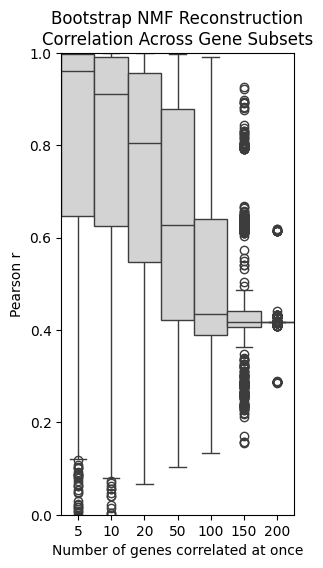

In [91]:
plt.figure(figsize=(3,6), dpi=100)
sns.boxplot(compute_bootstrap_correlation(
    (original, nmf_reconstruction),
    n_genes_range,
).result, color="lightgrey", width=1)
plt.ylim(0, 1)
plt.title("Bootstrap NMF Reconstruction\nCorrelation Across Gene Subsets")
plt.xlabel("Number of genes correlated at once")
plt.ylabel("Pearson r")

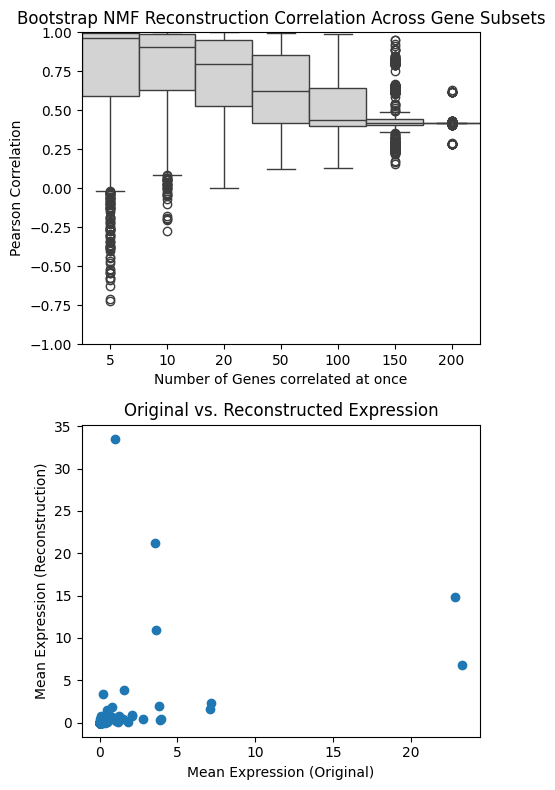

In [92]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (original, nmf_reconstruction),
        n_genes_range
    )
)

### Gene wise sampled data

#### without error

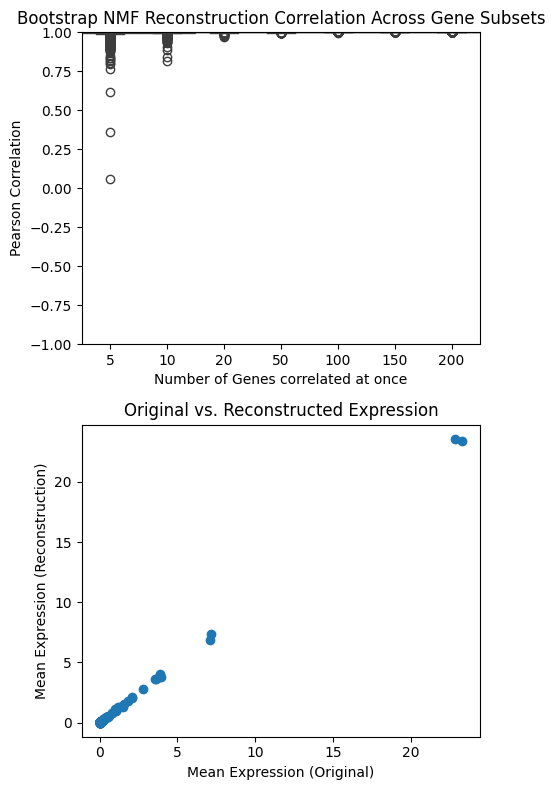

In [93]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (original, randomly_sampled),
        n_genes_range
    )
)

#### with error

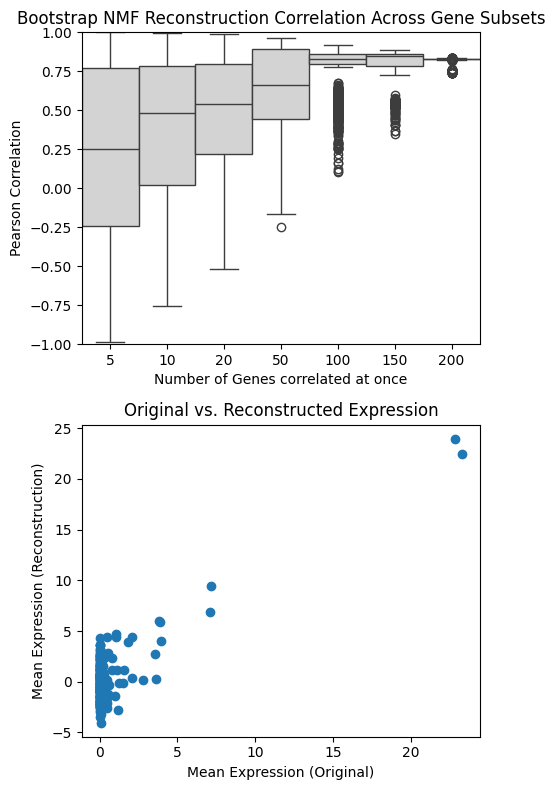

In [94]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (original, randomly_sampled_with_error),
        n_genes_range
    )
)

### Uniform Random Data

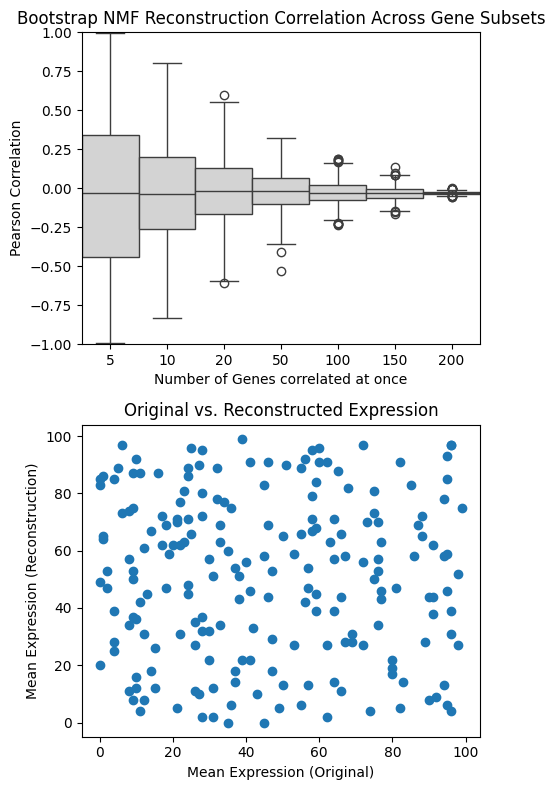

In [95]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (random_arr_1, random_arr_2),
        n_genes_range
    )
)

### Composite Data

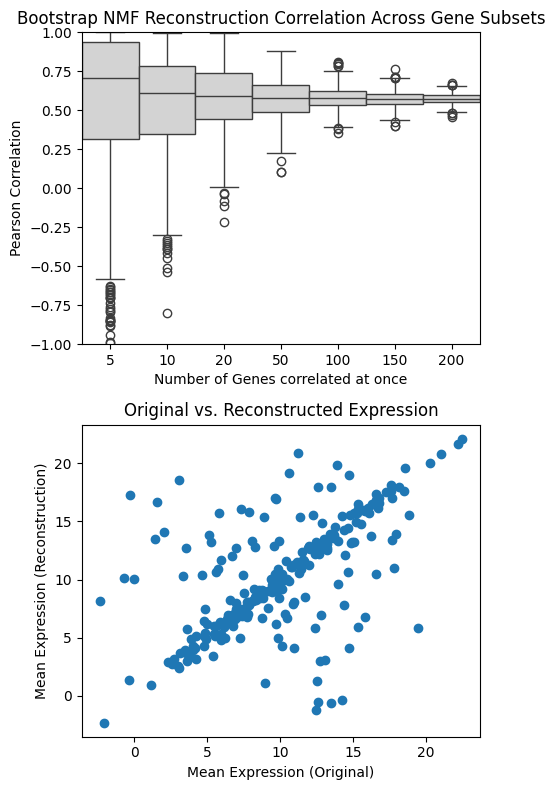

In [96]:
composite_data = (lambda arr: (arr[0], arr[1]))(np.hstack([
    np.array([np.random.normal(10, 5, 100), np.random.normal(10, 5, 100)]),  # uncorrelated data
    (lambda arr: np.array([arr, arr + np.random.normal(0, 0.5, arr.shape[0])]))(np.random.normal(10, 5, 150)),  # correlated data
]))

plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        composite_data,
        n_genes_range
    )
)

In [97]:
reconstruct_from_nmf_res(non_negative_factorization_wrapped(
    adata_sc[:, shared_genes].X,
    n_components=3
))

array([[1.9863637e-02, 4.3315976e-03, 2.6749149e-01, ..., 1.2560410e-02,
        1.4753224e-03, 2.5324267e-01],
       [1.8836899e-02, 8.6905183e-03, 3.5570920e-01, ..., 2.6844541e-02,
        2.1249230e-03, 5.3345412e-01],
       [4.7197536e-02, 2.2320084e-02, 9.2253846e-01, ..., 7.1963094e-02,
        2.9603911e-03, 1.4387760e+00],
       ...,
       [9.1564824e-04, 1.3855113e-04, 9.0210699e-03, ..., 8.2010505e-05,
        3.0778637e-04, 9.1332488e-04],
       [1.6873218e-02, 3.0925358e-04, 1.5487415e-01, ..., 9.9574878e-05,
        3.7414770e-04, 8.9007281e-03],
       [5.3991459e-04, 1.4827531e-04, 5.6558484e-03, ..., 9.0153175e-05,
        3.3874609e-04, 7.7175233e-04]], dtype=float32)

In [98]:
test = (lambda X, n_components: reconstruct_from_nmf_res(
    non_negative_factorization_wrapped(
        X,
        n_components=n_components
    )
))

X = filter_by_obs_value(adata_sc[:, shared_genes], "celltype", celltype).X.toarray()
res = np.array([test(X[np.random.choice(X.shape[0], X.shape[0])], n_components=3).mean(axis=0) for _ in range(10)])

In [99]:
shared_genes_filtered = shared_genes[np.var(res, axis=0) < 0.01]
print(f"{len(shared_genes_filtered)=}")

len(shared_genes_filtered)=184


In [100]:
original_filtered = filter_by_obs_value(adata_sp, "celltype", celltype)[:, shared_genes_filtered].X.mean(axis=0)

nmf_reconstruction_filtered = nmf_count_reconstruction(
    *tuple(map(lambda adata: adata[adata.obs["celltype"] == celltype], (adata_sp, adata_sc))),
    3,
    shared_genes_filtered
).mean(axis=0)
n_genes_range_filtered = [n for n in n_genes_range if n < len(shared_genes_filtered)]

In [101]:
n_genes_range

[5, 10, 20, 50, 100, 150, 200]

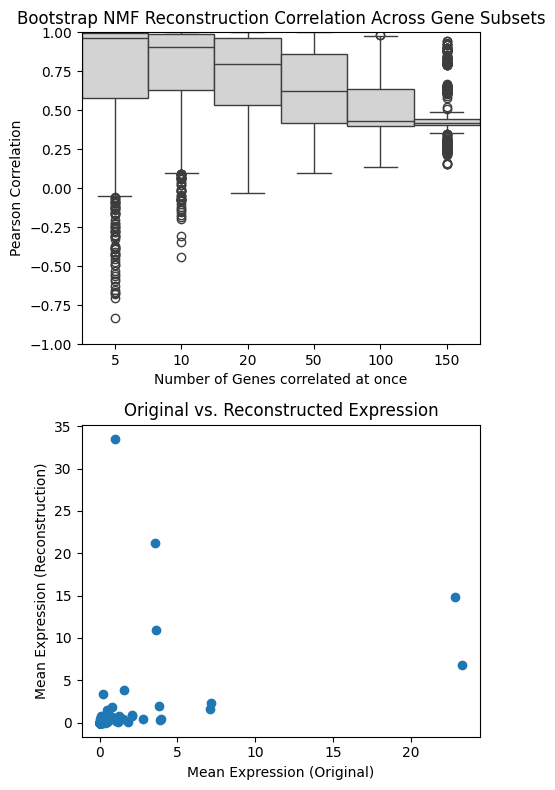

In [102]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (original, nmf_reconstruction),
        n_genes_range_filtered
    )
)

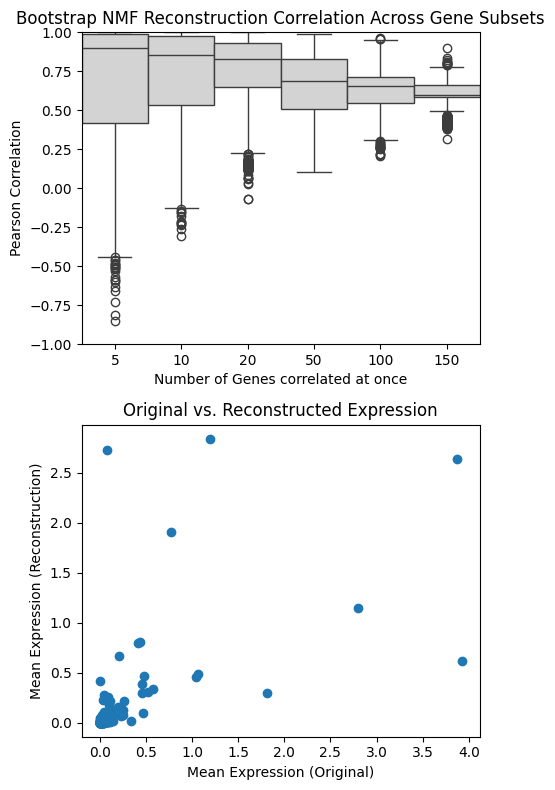

In [103]:
plot_bootstrap_correlation(
    compute_bootstrap_correlation(
        (original_filtered, nmf_reconstruction_filtered),
        n_genes_range_filtered
    )
)

In [104]:
pearsonr_nmf_reconstruction(
    *tuple(map(lambda adata: filter_by_obs_value(adata, "celltype", celltype), (adata_sp, adata_sc))),
    n_components=8,
    shared_genes=shared_genes#shared_genes_filtered
)

0.8179335594177246

(array([190.,   5.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   2.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.        , 0.03867878, 0.07735756, 0.11603634, 0.15471512,
        0.1933939 , 0.23207268, 0.27075148, 0.30943024, 0.34810901,
        0.3867878 , 0.4254666 , 0.46414536, 0.50282413, 0.54150295,
        0.58018172, 0.61886048, 0.65753925, 0.69621801, 0.73489684,
        0.7735756 , 0.81225437, 0.85093319, 0.

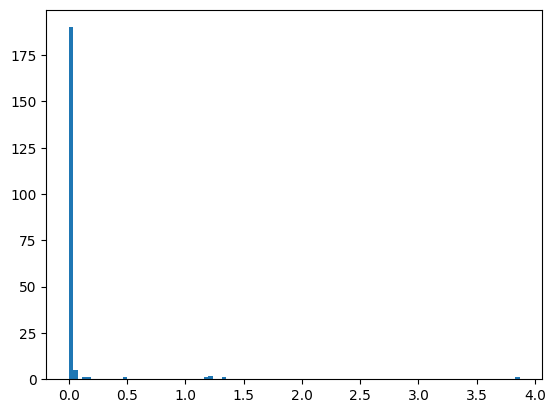

In [105]:
plt.hist(np.var(res, axis=0), bins=100)